In [142]:
import pandas as pd
import numpy as np

# Data Pre-processing

In [143]:
#path = r"C:\Users\prabh\Desktop\documents@desktop\AI Intern\myenv\sussex\KTP_task_datasets.xls"
path = 'KTP_task_datasets.xls'

In [ ]:
# Read the Excel file and load the data into DataFrames
df_lotA = pd.read_excel(path, sheet_name='Lot A014', header=[0,1])
df_lotB = pd.read_excel(path, sheet_name='Lot B025', header=[0,1])

df_lotA.head(2)

Start Date          Pull Date      Set down day   \
  Unnamed: 0_level_1 Unnamed: 1_level_1 Unnamed: 2_level_1   
0         2025-12-18         2026-01-08                  0   
1         2025-12-18         2026-01-08                  0   

  length of exposure (days)               Oven            T (° C)  \
         Unnamed: 3_level_1 Unnamed: 4_level_1 Unnamed: 5_level_1   
0                        21             Oven 2                 70   
1                        21             Oven 4                 65   

                 %RH    Analyst Assay (mg/tablet)          Imp RRT 0.92 (%)  \
  Unnamed: 6_level_1 (initials)          sample 1 sample 2         sample 1   
0                 11         RG             8.185    8.119            0.288   
1                 25         SS            11.184   10.702            0.246   

           IMP RRT 1.23 (%)           
  Sample 2         sample 1 Sample 2  
0    0.282            0.074    0.074  
1    0.215            0.134    0.136

In [ ]:
# check the column names of the DataFrame
df_lotA.columns

MultiIndex([(               'Start Date', 'Unnamed: 0_level_1'),
            (                'Pull Date', 'Unnamed: 1_level_1'),
            (            'Set down day ', 'Unnamed: 2_level_1'),
            ('length of exposure (days)', 'Unnamed: 3_level_1'),
            (                     'Oven', 'Unnamed: 4_level_1'),
            (                  'T (° C)', 'Unnamed: 5_level_1'),
            (                      '%RH', 'Unnamed: 6_level_1'),
            (                  'Analyst',         '(initials)'),
            (        'Assay (mg/tablet)',           'sample 1'),
            (        'Assay (mg/tablet)',           'sample 2'),
            (         'Imp RRT 0.92 (%)',           'sample 1'),
            (         'Imp RRT 0.92 (%)',           'Sample 2'),
            (         'IMP RRT 1.23 (%)',           'sample 1'),
            (         'IMP RRT 1.23 (%)',           'Sample 2')],
           )

In [60]:
df_lotB.columns

MultiIndex([(               'Start Date', 'Unnamed: 0_level_1'),
            (                'Pull Date', 'Unnamed: 1_level_1'),
            (            'Set down day ', 'Unnamed: 2_level_1'),
            ('length of exposure (days)', 'Unnamed: 3_level_1'),
            (                     'Oven', 'Unnamed: 4_level_1'),
            (                  'T (° C)', 'Unnamed: 5_level_1'),
            (                      '%RH', 'Unnamed: 6_level_1'),
            (                  'Analyst',         '(initials)'),
            (        'Assay (mg/tablet)',           'sample 1'),
            (        'Assay (mg/tablet)',           'sample 2'),
            (         'Imp RRT 0.92 (%)',           'sample 1'),
            (         'Imp RRT 0.92 (%)',           'Sample 2'),
            (         'IMP RRT 1.23 (%)',           'sample 1'),
            (         'IMP RRT 1.23 (%)',           'Sample 2')],
           )

In [61]:
df_lotA ['lot'] = 'A014'
df_lotB ['lot'] = 'B025'

df = pd.concat([df_lotA, df_lotB], axis=0, ignore_index=True)
df.shape

(40, 15)

In [62]:
df.columns = [top if 'Unnamed' in str(bot) else f"{top}_{bot}" for top, bot in df.columns]
df.columns

Index(['Start Date', 'Pull Date', 'Set down day ', 'length of exposure (days)',
       'Oven', 'T (° C)', '%RH', 'Analyst_(initials)',
       'Assay (mg/tablet)_sample 1', 'Assay (mg/tablet)_sample 2',
       'Imp RRT 0.92 (%)_sample 1', 'Imp RRT 0.92 (%)_Sample 2',
       'IMP RRT 1.23 (%)_sample 1', 'IMP RRT 1.23 (%)_Sample 2', 'lot_'],
      dtype='str')

In [63]:
# rename the columns to remove the multi-index and make them more readable

df = df.rename(columns={
    'Start Date': 'start_date',
    'Pull Date':'pull_date',
    'Set down day ':'set_down_day',
    'length of exposure (days)': 'exposure_days',
    'Oven':'oven',
    'T (° C)':'temp_c',
    '%RH': 'rh_in_percent',
    'Analyst_(initials)':'analyst',
    'Assay (mg/tablet)_sample 1':'assay_sample1',
    'Assay (mg/tablet)_sample 2':'assay_sample2',
    'Imp RRT 0.92 (%)_sample 1':'imp_rrt_092_sample1',
    'Imp RRT 0.92 (%)_Sample 2':'imp_rrt_092_sample2',
    'IMP RRT 1.23 (%)_sample 1':'imp_rrt_123_sample1',
    'IMP RRT 1.23 (%)_Sample 2':'imp_rrt_123_sample2',
    'lot_':'lot'
    
})
df.head(2)

,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh_in_percent,analyst,assay_sample1,assay_sample2,imp_rrt_092_sample1,imp_rrt_092_sample2,imp_rrt_123_sample1,imp_rrt_123_sample2,lot
0,2025-12-18,2026-01-08,0,21,Oven 2,70,11,RG,8.185,8.119,0.288,0.282,0.074,0.074,A014
1,2025-12-18,2026-01-08,0,21,Oven 4,65,25,SS,11.184,10.702,0.246,0.215,0.134,0.136,A014


In [64]:
df[df['oven'] == 'n/a ']

,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh_in_percent,analyst,assay_sample1,assay_sample2,imp_rrt_092_sample1,imp_rrt_092_sample2,imp_rrt_123_sample1,imp_rrt_123_sample2,lot
19,NaT,NaT,21,0,n/a,control,control,SS,12.790,12.808,0.0,0.0,0.082,0.068,A014
39,NaT,NaT,21,0,n/a,control,control,SS,12.493,12.720,0.0,0.0,0.143,0.143,B025


In [ ]:
# Lets split the rows

# split control and stress rows
df_control = df[df['oven'] == 'n/a '].copy()
df_stress = df[df['oven'] != 'n/a '].copy()

print(f"Stress rows  : {len(df_stress)}")
print(f"Control rows : {len(df_control)}")

Stress rows  : 38
Control rows : 2


In [66]:
# The raw differences for assay
df_stress['assay_diff'] = abs(df_stress['assay_sample1'] - df_stress['assay_sample2'])

# difference as % of the row mean (CV)
df_stress['assay_mean_raw'] = df_stress[['assay_sample1', 'assay_sample2']].mean(axis=1)
df_stress['assay_cv_pct']   = (df_stress['assay_diff'] / df_stress['assay_mean_raw']) * 100

df_stress[['lot', 'oven', 'temp_c', 'rh_in_percent', 
    'assay_sample1', 'assay_sample2', 'assay_diff', 'assay_cv_pct']].round(2)

,lot,oven,temp_c,rh_in_percent,assay_sample1,assay_sample2,assay_diff,assay_cv_pct
0,A014,Oven 2,70,11,8.18,8.12,0.07,0.81
1,A014,Oven 4,65,25,11.18,10.70,0.48,4.40
2,A014,Oven 1,50,64,12.10,12.24,0.14,1.13
3,A014,Oven 3,60,80,11.52,11.10,0.42,3.74
4,A014,Oven 3,60,42,11.81,11.29,0.52,4.49
5,A014,Oven 3,60,21,11.72,11.69,0.03,0.28
6,A014,Oven 2,70,41,8.29,8.41,0.12,1.47
7,A014,Oven 4,65,63,10.52,10.64,0.12,1.17
8,A014,Oven 1,50,64,12.34,12.46,0.12,0.97
9,A014,Oven 1,50,64,12.53,12.54,0.01,0.10


In [ ]:

threshold = 2
# calculate co-efficient of variation (CV) for assay samples and flag rows exceeding threshold
# Flagged rows with CV% greater than threshold
flagged      = df_stress[df_stress['assay_cv_pct'] > threshold]
highest_cv   = df_stress.loc[df_stress['assay_cv_pct'].idxmax()]
high_temp_cv = df_stress.groupby('temp_c')['assay_cv_pct'].mean().sort_values(ascending=False)

print(f"Flagged: {len(flagged)} / {len(df_stress)} rows exceed {threshold}% CV")

print(f"Highest CV:"f"({highest_cv['lot']}, {highest_cv['oven']}, "
      f"{highest_cv['temp_c']} ° C , {highest_cv['rh_in_percent']}%) "
      f"— CV = {highest_cv['assay_cv_pct']:.2f}%")

print(f"\nMean assay CV% by temperature:")

print(high_temp_cv.round(2).to_string())

Flagged: 18 / 38 rows exceed 2% CV
Highest CV:(B025, Oven 2, 70 ° C , 11%) — CV = 5.43%

Mean assay CV% by temperature:
temp_c
70    2.48
60    2.21
65    1.89
50    0.57


In [68]:
# Assay duplicate check summary 
# Flagged   : 18/38 rows exceed 2% CV
# Highest   : (B025, Oven 2, 70°C/11%) at 5.43%
# Pattern   : CV increases with temperature - 70°C > 60°C > 65°C > 50°C
# Note      : 65°C sits lower than 60°C 
# Decision  : Lets average - flag as limitation in Q6

In [ ]:
# imp092 and imp123 check
df_stress['imp092_diff']     = abs(df_stress['imp_rrt_092_sample1'] - df_stress['imp_rrt_092_sample2'])
df_stress['imp092_mean_raw'] = df_stress[['imp_rrt_092_sample1', 'imp_rrt_092_sample2']].mean(axis=1)
df_stress['imp092_cv_pct']   = (df_stress['imp092_diff'] / df_stress['imp092_mean_raw']) * 100

# imp123 check
df_stress['imp123_diff']     = abs(df_stress['imp_rrt_123_sample1'] - df_stress['imp_rrt_123_sample2'])
df_stress['imp123_mean_raw'] = df_stress[['imp_rrt_123_sample1', 'imp_rrt_123_sample2']].mean(axis=1)
df_stress['imp123_cv_pct']   = (df_stress['imp123_diff'] / df_stress['imp123_mean_raw']) * 100

df_stress[['lot', 'oven', 'temp_c', 'rh_in_percent',
    'imp_rrt_092_sample1', 'imp_rrt_092_sample2',
    'imp092_diff', 'imp092_cv_pct', 'imp_rrt_123_sample1', 'imp_rrt_123_sample2',
    'imp123_diff', 'imp123_cv_pct']].round(2)

,lot,oven,temp_c,rh_in_percent,imp_rrt_092_sample1,imp_rrt_092_sample2,imp092_diff,imp092_cv_pct,imp_rrt_123_sample1,imp_rrt_123_sample2,imp123_diff,imp123_cv_pct
0,A014,Oven 2,70,11,0.29,0.28,0.01,2.11,0.07,0.07,0.00,0.00
1,A014,Oven 4,65,25,0.25,0.22,0.03,13.45,0.13,0.14,0.00,1.48
2,A014,Oven 1,50,64,0.22,0.22,0.00,0.00,0.19,0.19,0.00,1.05
3,A014,Oven 3,60,80,0.65,0.67,0.02,3.32,0.17,0.17,0.00,2.37
4,A014,Oven 3,60,42,0.53,0.54,0.01,2.62,0.18,0.18,0.00,0.00
5,A014,Oven 3,60,21,0.31,0.29,0.03,8.29,0.16,0.16,0.00,0.61
6,A014,Oven 2,70,41,0.51,0.47,0.04,7.74,0.12,0.13,0.00,0.80
7,A014,Oven 4,65,63,0.53,0.56,0.04,6.78,0.19,0.18,0.00,1.08
8,A014,Oven 1,50,64,0.18,0.18,0.01,3.31,0.20,0.20,0.00,1.01
9,A014,Oven 1,50,64,0.16,0.16,0.00,0.00,0.21,0.21,0.00,1.91


In [ ]:
# Summary for imp092 and imp123
for metric in ['imp092', 'imp123']:
    # calculate flagged rows, highest CV, and mean CV by temperature
    flagged    = df_stress[df_stress[f'{metric}_cv_pct'] > 2].dropna(subset=[f'{metric}_cv_pct'])
    highest    = df_stress.loc[df_stress[f'{metric}_cv_pct'].idxmax()]
    by_temp    = df_stress.groupby('temp_c')[f'{metric}_cv_pct'].mean().sort_values(ascending=False)
    
    print(f"\n{'-'*50}")
    print(f"{metric.upper()} check")
    
    print(f"Flagged: {len(flagged)} / {len(df_stress)} rows exceed 2% CV")
    print(f"Highest: "
          f"({highest['lot']}, {highest['oven']}, "
          f"{highest['temp_c']}°C) — CV = {highest[f'{metric}_cv_pct']:.2f}%")
    print(f"\nMean CV% by temperature:")
    print(by_temp.round(2).to_string())


--------------------------------------------------
IMP092 check
Flagged: 28 / 38 rows exceed 2% CV
Highest: (B025, Oven 4, 65°C) — CV = 26.83%

Mean CV% by temperature:
temp_c
65    10.66
70     6.03
60     3.27
50     1.76

--------------------------------------------------
IMP123 check
Flagged: 2 / 38 rows exceed 2% CV
Highest: (A014, Oven 2, 70°C) — CV = 2.60%

Mean CV% by temperature:
temp_c
65    1.27
50    1.20
60    1.10
70    0.63


In [71]:
# at the worst imp092 rows
high_imp092 = df_stress[df_stress['imp092_cv_pct'] > 10][
    ['lot', 'oven', 'temp_c', 'rh_in_percent',
     'imp_rrt_092_sample1', 'imp_rrt_092_sample2',
     'imp092_cv_pct']
].round(2).sort_values('imp092_cv_pct', ascending=False)

print(high_imp092.to_string())

     lot    oven temp_c rh_in_percent  imp_rrt_092_sample1  imp_rrt_092_sample2  imp092_cv_pct
21  B025  Oven 4     65            25                 0.28                 0.21          26.83
14  A014  Oven 2     70            11                 0.57                 0.45          23.83
1   A014  Oven 4     65            25                 0.25                 0.22          13.45
31  B025  Oven 4     65            25                 0.19                 0.17          11.70
27  B025  Oven 4     65            63                 0.52                 0.46          11.17


In [72]:
# oven 4 appears to be fluctuating. so, lets check oven nature.

oven_cv = df_stress.groupby('oven')['imp092_cv_pct'].agg(['mean', 'max', 'min','count']).round(2)
oven_cv.columns = ['mean_cv', 'max_cv', 'min_cv', 'n_rows']
oven_cv.sort_values('mean_cv', ascending=False)

,mean_cv,max_cv,min_cv,n_rows
oven,,,,
Oven 4,10.66,26.83,1.71,8
Oven 2,6.03,23.83,0.64,12
Oven 3,3.27,8.29,0.74,12
Oven 1,1.76,4.86,0.00,6


In [74]:
# average duplicates — stress rows only
df_stress['assay_mean']  = df_stress[['assay_sample1',       'assay_sample2']].mean(axis=1)
df_stress['imp092_mean'] = df_stress[['imp_rrt_092_sample1', 'imp_rrt_092_sample2']].mean(axis=1)
df_stress['imp123_mean'] = df_stress[['imp_rrt_123_sample1', 'imp_rrt_123_sample2']].mean(axis=1)

In [84]:
# oven effect on outcomes
oven_effect = df_stress.groupby('oven')[['temp_c', 'rh_in_percent','assay_mean', 'imp092_mean', 'imp123_mean']].mean().round(3).sort_values('temp_c')
print("Mean outcomes by oven:")
print(oven_effect)

Mean outcomes by oven:
       temp_c rh_in_percent  assay_mean  imp092_mean  imp123_mean
oven                                                             
Oven 1   50.0          64.0      12.318        0.195        0.254
Oven 3   60.0     47.666667      11.843        0.377        0.284
Oven 4   65.0          44.0      11.363        0.290        0.315
Oven 2   70.0     43.666667      10.454        0.432        0.452


In [85]:
# Pattern: 
# Clearly temperature is associated with the outcomes. The higher the temperature, the lower the assay and higher the impurities.
# but with imp092, the 65°C sits lower than 60°C. This is likely due to the oven effect. 
# Oven 4 (65°C) has a higher CV% than Oven 2 (60°C). oven 4 has (Mean_cv = 10.66 ; MAX_CV = 26.83) higher than all other ovens.
# But, this overn effect is not noticed in imp123.


# Trends:
# 1. ASSAY
# Oven 1 (50°C) : 12.318 --> least degradation
# Oven 3 (60°C) : 11.843  --> moderate
# Oven 4 (65°C) : 11.363  --> more degradation
# Oven 2 (70°C) : 10.454  --> most degradation
# Clear trend: assay drops as temperature rises

# 2. IMP092 
# Oven 1 (50°C) : 0.195   --> lowest impurity
# Oven 4 (65°C) : 0.290   --> moderate
# Oven 3 (60°C) : 0.377   --> higher than 65°C — unexpected
# Oven 2 (70°C) : 0.432   --> highest impurity
# Notes:Oven 3 (60°C) > Oven 4 (65°C) - humidity may be playing a role here
#       Oven 3 tests include 80% RH which is highest in the dataset. 
#       But when RH = 80%, the values seems normal. No high CV% or high impurity. So, the RH effect is not clear.

# 3. IMP123
# Oven 1 (50°C) : 0.254   --> lowest
# Oven 3 (60°C) : 0.284   --> moderate
# Oven 4 (65°C) : 0.315   --> higher
# Oven 2 (70°C) : 0.452   --> highest
# Pattern is clear.

In [86]:
# co-relation Analysis:

corr_cols = ['temp_c', 'rh_in_percent', 'exposure_days', 
             'assay_mean', 'imp092_mean', 'imp123_mean']

corr = df_stress[corr_cols].corr().round(2)
print(corr)

               temp_c  rh_in_percent  exposure_days  assay_mean  imp092_mean  \
temp_c           1.00          -0.27          -0.36       -0.55         0.41   
rh_in_percent   -0.27           1.00          -0.23        0.33         0.05   
exposure_days   -0.36          -0.23           1.00       -0.44         0.20   
assay_mean      -0.55           0.33          -0.44        1.00        -0.37   
imp092_mean      0.41           0.05           0.20       -0.37         1.00   
imp123_mean      0.35           0.36          -0.84        0.41        -0.01   

               imp123_mean  
temp_c                0.35  
rh_in_percent         0.36  
exposure_days        -0.84  
assay_mean            0.41  
imp092_mean          -0.01  
imp123_mean           1.00  


In [93]:
# average duplicates — stress rows only
df_control['assay_mean']  = df_control[['assay_sample1',       'assay_sample2']].mean(axis=1)
df_control['imp092_mean'] = df_control[['imp_rrt_092_sample1', 'imp_rrt_092_sample2']].mean(axis=1)
df_control['imp123_mean'] = df_control[['imp_rrt_123_sample1', 'imp_rrt_123_sample2']].mean(axis=1)

# Q1. Key Features:

In [ ]:


# 1. Structure:

print("Rows             :", len(df_stress))
print("Lots             :", df_stress['lot'].unique().tolist())
print("Temp (°C)        :", sorted(df_stress['temp_c'].unique().tolist()))
print("Humidity %       :", sorted(df_stress['rh_in_percent'].unique().tolist()))
print("Days of exposure :", sorted(df_stress['exposure_days'].unique().tolist()))

Rows             : 38
Lots             : ['A014', 'B025']
Temp (°C)        : [50, 60, 65, 70]
Humidity %       : [11, 21, 25, 41, 42, 63, 64, 79, 80]
Days of exposure : [1, 2, 5, 6, 7, 14, 17, 19, 20, 21]


In [98]:
# oven to temperature mapping
print("\nOven --> Temperature:")
print(df_stress.groupby('oven')['temp_c'].first().to_string())


Oven --> Temperature:
oven
Oven 1    50
Oven 2    70
Oven 3    60
Oven 4    65


In [99]:
# control baseline
print("\nBaseline (no stress):")
print(df_control[['lot', 'assay_mean', 'imp092_mean', 'imp123_mean']].round(3).to_string(index=False))


Baseline (no stress):
 lot  assay_mean  imp092_mean  imp123_mean
A014      12.799          0.0        0.075
B025      12.606          0.0        0.143


In [ ]:
# outcome summary across stress conditions
print("\nOutcome ranges (stress rows):")
print(df_stress[['assay_mean', 'imp092_mean', 'imp123_mean']].describe().round(3).to_string())


Outcome ranges (stress rows):
       assay_mean  imp092_mean  imp123_mean
count      38.000       38.000       38.000
mean       11.379        0.347        0.339
std         1.202        0.162        0.199
min         8.152        0.134        0.074
25%        11.161        0.224        0.191
50%        11.845        0.296        0.292
75%        12.174        0.492        0.464
max        12.539        0.718        0.885


Q1 : Observations

In [ ]:
# Q1 - Key observations

# 38 stress rows: 19 per lot (A014, B025)
# 4 temperatures: 50, 60, 65, 70°C - one oven per temperature
# Humidity: 11–80% (not all combinations tested at every temperature)
# Time window: 1–21 days.

# Baseline: both lots start similar --> A014: 12.80, B025: 12.61 (assay)
# imp092 is 0.0 at baseline - only appears under stress
# imp123 already present at baseline --> A014: 0.075, B025: 0.143

# Under stress:
# assay dropped to as low as 8.15 - temperature is main driver
# imp092 rose to 0.72 - temperature driven
# imp123 rose to 0.89 - exposure time driven (strongest correlation -0.84)

# Data quality flag:
# imp092 at Oven 4 (65°C) unreliable - CV up to 26.83%
# Oven and temperature fully confounded - cannot separate effects

# Dataset characteristics relevant to analysis:
# 1. Oven and temperature fully confounded
# 2. Exposure Time window (fully co-related with imp123 --> -0.84)
# 3. Humidity - less impactful. 
# 4. Oven 4 (65°C) has higher CV% for imp092 than other ovens - likely due to oven effect.
# 5. The dataset is small - only 38 stress rows. So, the analysis will be limited in scope.


# Q2: trends, patterns and hypothetical relationships 

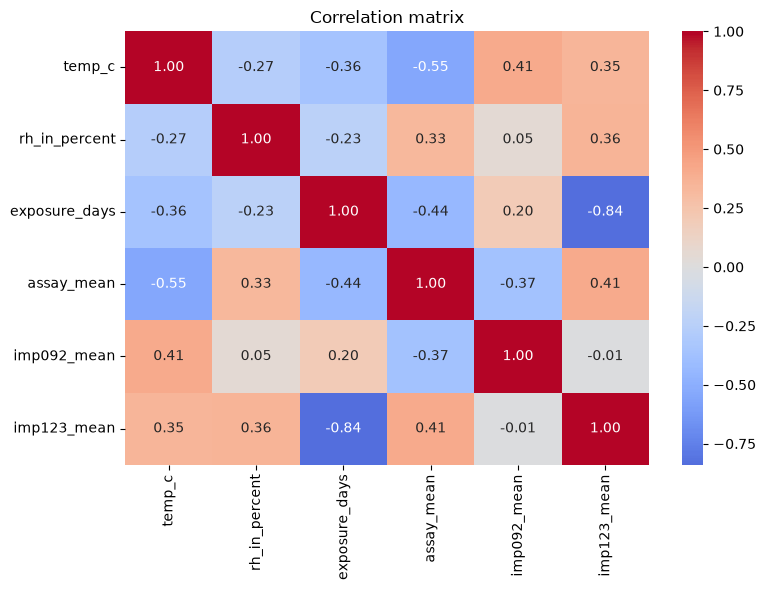

In [108]:
# heatmap
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            ax=ax)

ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

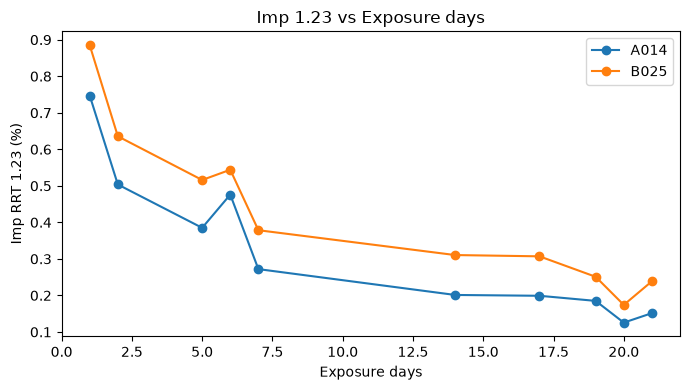

In [ ]:
# imp123 vs exposure days
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the average imp123_mean for each lot against exposure_days
for lot, grp in df_stress.groupby('lot'):
    avg = grp.groupby('exposure_days')['imp123_mean'].mean()
    ax.plot(avg.index, avg.values, marker='o', label=lot)

ax.set_xlabel('Exposure days')
ax.set_ylabel('Imp RRT 1.23 (%)')
ax.set_title('Imp 1.23 vs Exposure days')
ax.legend()
plt.tight_layout()
plt.show()

- Imp RRT 1.23 vs Exposure Days

Imp 1.23 decreases steadily as exposure days increase, which matches the strong negative correlation (r = -0.84). 
B025 starts off higher than A014 at the beginning, but both reach similar levels by day 21. 
This suggests that Imp 1.23 builds up early and then levels off, with time having a bigger impact than temperature or humidity.

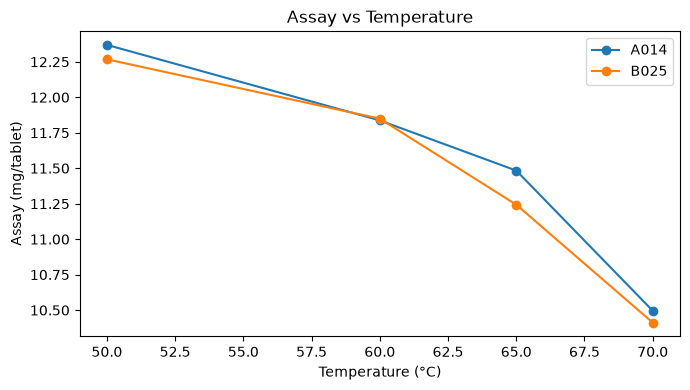

In [ ]:
# Assay vs temperature
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the average assay_mean for each lot against temperature
for lot, grp in df_stress.groupby('lot'):
    grp_avg = grp.groupby('temp_c')['assay_mean'].mean()
    ax.plot(grp_avg.index, grp_avg.values, marker='o', label=lot)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Assay (mg/tablet)')
ax.set_title('Assay vs Temperature')
ax.legend()
plt.tight_layout()
plt.show()

Assay vs Temperature

Assay drops consistently as temperature increases for both lots. 
Both formulations behave similarly at 50°C and 60°C but begin to 
diverge at 65°C and above - B025 showing slightly more loss at higher 
temperatures.

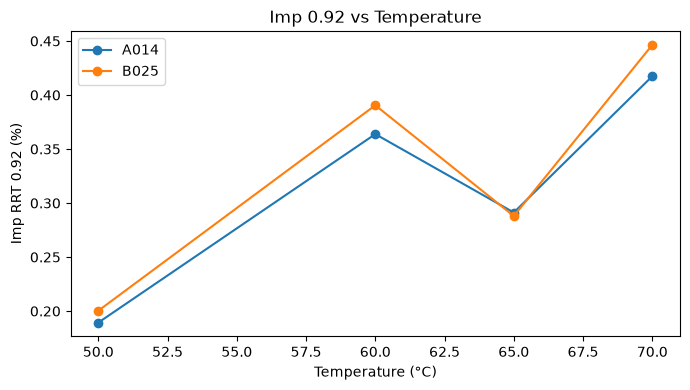

In [ ]:
# Imp092 vs temperature
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the average imp092_mean for each lot against temperature
for lot, grp in df_stress.groupby('lot'):
    avg = grp.groupby('temp_c')['imp092_mean'].mean()
    ax.plot(avg.index, avg.values, marker='o', label=lot)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Imp RRT 0.92 (%)')
ax.set_title('Imp 0.92 vs Temperature')
ax.legend()
plt.tight_layout()
plt.show()

Imp RRT 0.92 vs Temperature

Imp 0.92 generally rises with temperature for both lots, lowest at 50°C and highest at 70°C. 
- The unexpected dip at 65°C is likely due to high 
measurement variability at Oven 4 (CV up to 26.83%) 
- Should interpret 65°C imp092 values with caution.

# Q3: Factors drive degradation

In [120]:
# imp092 rise from baseline vs temperature
# baseline imp092 is 0 for both lots — so mean value = absolute change

df_stress.groupby(['lot', 'temp_c'])['imp092_mean'].mean().round(3)

lot   temp_c
A014  50        0.189
      60        0.364
      65        0.291
      70        0.417
B025  50        0.200
      60        0.390
      65        0.288
      70        0.446
Name: imp092_mean, dtype: float64

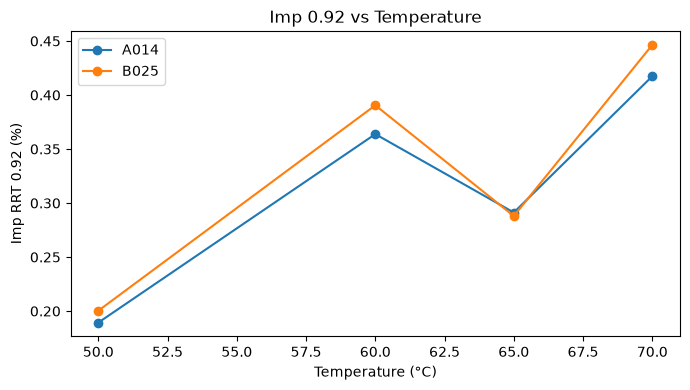

In [ ]:
# imp092 vs temperature
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the average imp092_mean for each lot against temperature
for lot, grp in df_stress.groupby('lot'):
    avg = grp.groupby('temp_c')['imp092_mean'].mean()
    ax.plot(avg.index, avg.values, marker='o', label=lot)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Imp RRT 0.92 (%)')
ax.set_title('Imp 0.92 vs Temperature')
ax.legend()
plt.tight_layout()
plt.show()

Observation:

Imp 0.92 rises with temperature overall - lowest at 50°C, highest at 70°C. The dip at 65°C is likely due to Oven 4 measurement unreliability, not a real chemical effect.

In [122]:
# imp123 vs exposure days
df_stress.groupby(['lot', 'exposure_days'])['imp123_mean'].mean().round(3)

lot   exposure_days
A014  1                0.747
      2                0.504
      5                0.385
      6                0.476
      7                0.272
      14               0.201
      17               0.199
      19               0.185
      20               0.126
      21               0.151
B025  1                0.885
      2                0.636
      5                0.516
      6                0.544
      7                0.378
      14               0.310
      17               0.307
      19               0.251
      20               0.174
      21               0.239
Name: imp123_mean, dtype: float64

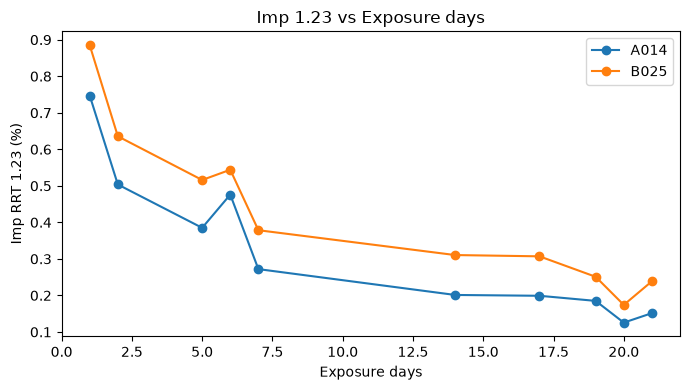

In [ ]:
# imp123 vs exposure days
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the average imp123_mean for each lot against exposure_days
for lot, grp in df_stress.groupby('lot'):
    avg = grp.groupby('exposure_days')['imp123_mean'].mean()
    ax.plot(avg.index, avg.values, marker='o', label=lot)

ax.set_xlabel('Exposure days')
ax.set_ylabel('Imp RRT 1.23 (%)')
ax.set_title('Imp 1.23 vs Exposure days')
ax.legend()
plt.tight_layout()
plt.show()

Observation:

Imp 1.23 drops consistently over time for both lots — highest at day 1, stabilising toward day 21. B025 starts higher than A014 but both follow the same pattern. 

Q3: Factors influencing degradation

 Temperature --> primary driver of assay loss (-0.55)
               assay drops ~18% at 70°C vs ~3% at 50°C

 Temperature --> primary driver of imp092 rise (0.41)
               rises from 0.19 at 50°C to 0.43 at 70°C
               65°C readings unreliable — Oven 4 CV issue

Exposure time --> primary driver of imp123 (−0.84)
                 drops from ~0.75 at day 1 to ~0.15 by day 1
                 strongest relationship in the entire dataset


# Q4: relative performance of the two prototype formulation

In [125]:
# A014 vs B025 — head to head summary
summary = df_stress.groupby('lot')[['assay_mean', 
                                    'imp092_mean', 
                                    'imp123_mean']].mean().round(3)
print(summary)

      assay_mean  imp092_mean  imp123_mean
lot                                       
A014      11.423        0.338        0.289
B025      11.334        0.357        0.389


In [128]:
# Assay   : A014 (11.423) > B025 (11.334) --> A014 retains more active ingredient
# Imp092  : A014 (0.338)  < B025 (0.357)  --> A014 produces less imp092
# Imp123  : A014 (0.289)  < B025 (0.389)  --> A014 produces significantly less imp123
#

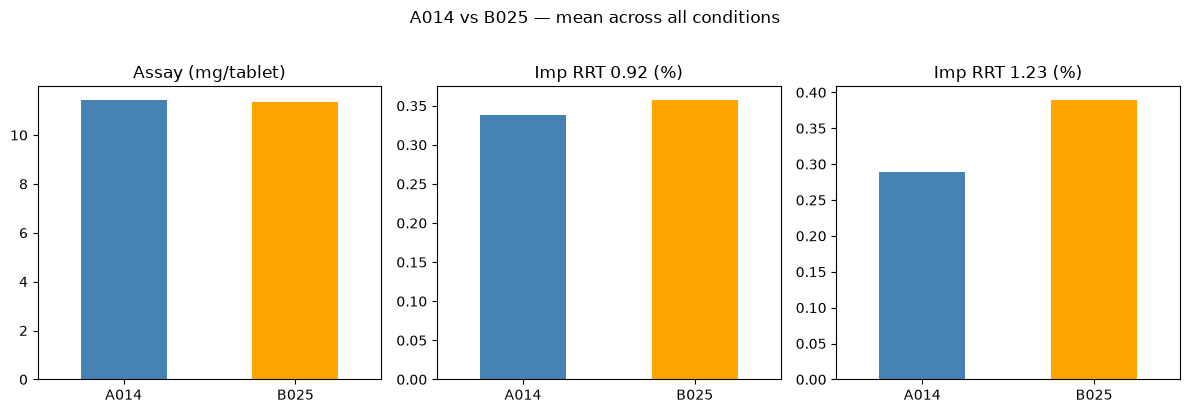

In [ ]:
# A014 vs B025 bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = ['assay_mean', 'imp092_mean', 'imp123_mean']
titles  = ['Assay (mg/tablet)', 'Imp RRT 0.92 (%)', 'Imp RRT 1.23 (%)']

for ax, metric, title in zip(axes, metrics, titles):
    summary[metric].plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('A014 vs B025 - mean across all conditions', y=1.02)
plt.tight_layout()
plt.show()

Q4 — Relative Performance of A014 vs B025

A014 outperforms B025 on all three stability metrics:
- Retains slightly higher assay (11.42 vs 11.33 mg/tablet)
- Produces less Imp 0.92 (0.338 vs 0.357%)
- Produces significantly less Imp 1.23 (0.289 vs 0.389%)

The biggest difference is in Imp 1.23. B025 starts higher at baseline (0.143 vs 0.075) but stays higher throughout, averaging 0.389% vs 0.289% for A014. This gap at baseline suggests the two formulations are chemically different from the start, not just responding differently to stress.

Recommendation: A014 is the more stable formulation.

UNcertainities:
- Only 21 days of data - long term unknown
- Imp 0.92 comparison weakened by Oven 4 measurement issues
- Small dataset - 19 measurements per lot limits confidence

# Q5: Modelling

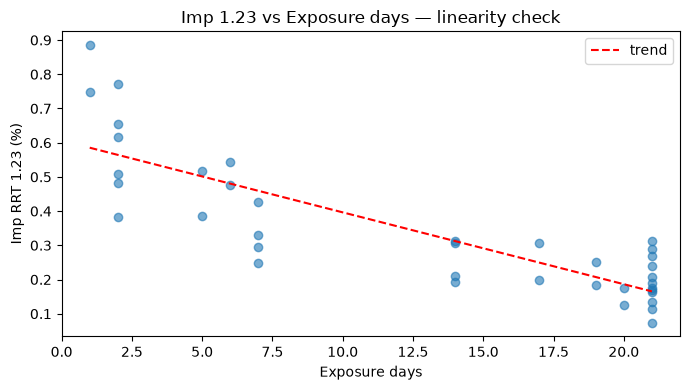

In [129]:
# scatter plot — does imp123 vs days look linear?
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(df_stress['exposure_days'], df_stress['imp123_mean'], alpha=0.6)

# add a trend line
m, b = np.polyfit(df_stress['exposure_days'], df_stress['imp123_mean'], 1)
x = np.linspace(df_stress['exposure_days'].min(), df_stress['exposure_days'].max(), 100)
ax.plot(x, m*x + b, color='red', linestyle='--', label='trend')

ax.set_xlabel('Exposure days')
ax.set_ylabel('Imp RRT 1.23 (%)')
ax.set_title('Imp 1.23 vs Exposure days — linearity check')
ax.legend()
plt.tight_layout()
plt.show()

In [131]:
# Observation:
# the relationship looks broadly linear & downward trend is clear
# scatter is higher at early time points 
# linear regression is a reasonable starting point

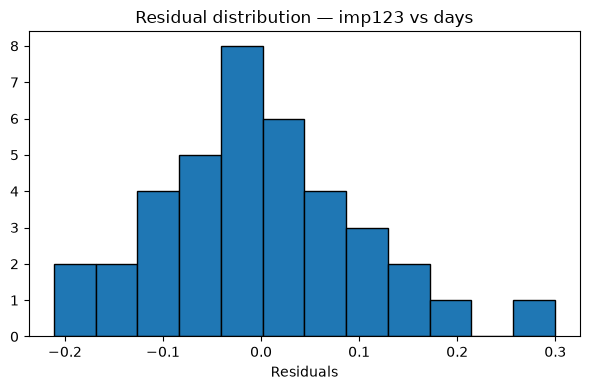

In [135]:
# residual check
from sklearn.linear_model import LinearRegression

x = df_stress[['exposure_days']]
y = df_stress['imp123_mean']

model = LinearRegression()
model.fit(x, y)

residuals = y - model.predict(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=12, edgecolor='black')
ax.set_xlabel('Residuals')
ax.set_title('Residual distribution — imp123 vs days')
plt.tight_layout()
plt.show()

- residuals roughly normally distributed — centred at 0
- slight right tail (one outlier at 0.3) 
- linear regression is justified 

In [136]:
# fit linear regression 
print(f"Slope     : {model.coef_[0]:.4f}  (imp123 change per day)")
print(f"Intercept : {model.intercept_:.4f}")
print(f"R²        : {model.score(x, y):.3f}")

Slope     : -0.0210  (imp123 change per day)
Intercept : 0.6064
R²        : 0.710


In [137]:
# predict imp123 at future time points
days_future = [30, 60, 90]

for d in days_future:
    pred = model.intercept_ + model.coef_[0] * d
    print(f"Day {d:3d} : predicted imp123 = {pred:.3f}%")

Day  30 : predicted imp123 = -0.024%
Day  60 : predicted imp123 = -0.654%
Day  90 : predicted imp123 = -1.284%


Impurity can't go below zero. we need an exponential decay model as it naturally flattens toward zero.

In [138]:
# exponential decay model
from scipy.optimize import curve_fit

def exp_decay(t, a, b):
    return a * np.exp(-b * t)

x = df_stress['exposure_days'].values
y = df_stress['imp123_mean'].values

popt, _ = curve_fit(exp_decay, x, y, p0=[0.6, 0.05])
a, b = popt

print(f"a (initial level) : {a:.4f}")
print(f"b (decay rate)    : {b:.4f}")
print(f"Half life         : {np.log(2)/b:.1f} days")

a (initial level) : 0.6852
b (decay rate)    : 0.0668
Half life         : 10.4 days


In [139]:
# predict future time points with exponential model
days_future = [30, 60, 90]

for d in days_future:
    pred = exp_decay(d, a, b)
    print(f"Day {d:3d} : predicted imp123 = {pred:.3f}%")

Day  30 : predicted imp123 = 0.092%
Day  60 : predicted imp123 = 0.012%
Day  90 : predicted imp123 = 0.002%


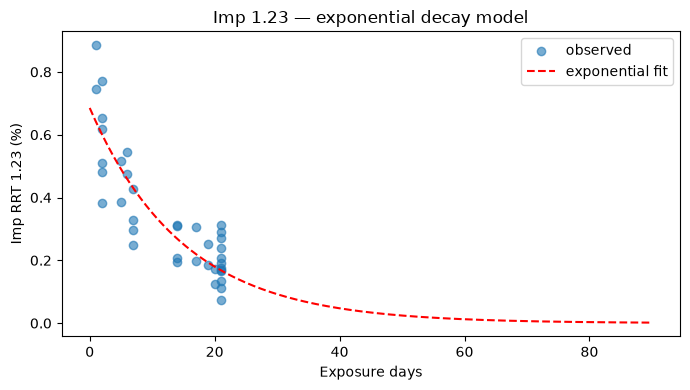

In [140]:
# Plot exponential model vs actual data
fig, ax = plt.subplots(figsize=(7, 4))

# actual data
ax.scatter(x, y, label='observed', alpha=0.6)

# exponential fit
x_line = np.linspace(0, 90, 200)
ax.plot(x_line, exp_decay(x_line, a, b), 
        color='red', linestyle='--', label='exponential fit')

ax.set_xlabel('Exposure days')
ax.set_ylabel('Imp RRT 1.23 (%)')
ax.set_title('Imp 1.23 — exponential decay model')
ax.legend()
plt.tight_layout()
plt.show()

**Q5 - Modelling**

An exponential decay model was fitted to Imp 1.23 vs exposure days: the strongest relationship in the dataset (r = -0.84).

imp123 = 0.685 × exp(−0.067 × days)
(initial level) : 0.6852
(decay rate)    : 0.0668
Half life         : 10.4 days

The model estimates a half life of ~10 days, meaning imp123 halves roughly every 10 days under these accelerated conditions. Predictions remain meaningful (positive) unlike a linear model which gave negative values beyond day 30.

Limitations: model consideres, all conditions as mixed. 
Not considered temperature or humidity separately.

# Q6 : Limitations and future improvements

### Limitations

1. Only three weeks of data - too short to draw firm conclusions on long term shelf life.

2. Most conditions measured at a single time point - cannot see how degradation progresses within a condition.

3. Oven and temperature are the same thing in this study — 
any oven-related effects, influence temperature.

4. imp092 measurements at 65°C are unreliable — high variability between duplicates weakens conclusions for that condition.

### What would improve the study

1. More time points and extend time window: 
   Repeat measurements at the same conditions 
   over more months to build proper degradation curves.

2. Fix the imp092 variability at 65°C 
   Investigate whether this is an instrument or sample preparation issue before the next study.

3. Humidity design: Test the same humidity levels at every temperature to allow clean separation of temperature and humidity effects.